# 01 - Store Sales Forecasting - Baseline LightGBM

## Objective
Build a baseline model for store sales forecasting using basic temporal features, lag features and chronological validation.

## Pipeline Overview

This baseline experiment follows these steps:

1. Load train and test data
2. Perform basic preprocessing
3. Create temporal features
4. Create lag features
5. Clean missing lag values
6. Encode categorical variables
7. Split data chronologically
8. Train a LightGBM baseline model
9. Evaluate performance with RMSLE
10. Perform a first error analysis

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_log_error
from lightgbm import LGBMRegressor

In [2]:
SEED = 42
SAMPLE_SIZE = 200_000
DATA_DIR = Path("../data")  
TARGET = "sales"

print("Setup OK")
print("Data dir:", DATA_DIR.resolve())

Setup OK
Data dir: /home/donatocorbacio/projects/store-sales-project/data


In [3]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
display(train.head())

Train shape: (3000888, 6)
Test shape: (28512, 5)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
print("\nTrain info:")
train.info()

print("\nMissing values:")
display(train.isnull().sum())

print("\nDate range:")
print("Min date:", train["date"].min())
print("Max date:", train["date"].max())


Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB

Missing values:


id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


Date range:
Min date: 2013-01-01 00:00:00
Max date: 2017-08-15 00:00:00


## Data preprocessing
Sort the dataset by `store_nbr`, `family`, and `date` before creating lag features.

This is essential in panel time series forecasting because lag features must be computed on a temporally ordered series.

In [5]:
train = train.sort_values(["store_nbr", "family", "date"]).copy()
test = test.sort_values(["store_nbr", "family", "date"]).copy()

print("Sorting completed.")
display(train.head())

Sorting completed.


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0


In [9]:
for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)

display(train[["date", "year", "month", "day", "dayofweek", "weekofyear"]].head())

,date,year,month,day,dayofweek,weekofyear
89100,2013-02-20,2013,2,20,2,8
115830,2013-03-07,2013,3,7,3,10
147906,2013-03-25,2013,3,25,0,13
196020,2013-04-21,2013,4,21,6,16
254826,2013-05-24,2013,5,24,4,21


## Lag Features

Lag features are used to capture temporal dependencies.

- lag_1: previous day sales
- lag_7: weekly pattern

These features allow the model to learn short-term and weekly dynamics.

In [10]:
train["lag_1"] = train.groupby(["store_nbr", "family"])[TARGET].shift(1)
train["lag_7"] = train.groupby(["store_nbr", "family"])[TARGET].shift(7)

display(
    train[["date", "store_nbr", "family", "sales", "lag_1", "lag_7"]].head(10)
)

,date,store_nbr,family,sales,lag_1,lag_7
89100,2013-02-20,1,AUTOMOTIVE,2.0,NaN,NaN
115830,2013-03-07,1,AUTOMOTIVE,0.0,2.0,NaN
147906,2013-03-25,1,AUTOMOTIVE,4.0,0.0,NaN
196020,2013-04-21,1,AUTOMOTIVE,1.0,4.0,NaN
254826,2013-05-24,1,AUTOMOTIVE,2.0,1.0,NaN
308286,2013-06-23,1,AUTOMOTIVE,3.0,2.0,NaN
315414,2013-06-27,1,AUTOMOTIVE,3.0,3.0,NaN
318978,2013-06-29,1,AUTOMOTIVE,5.0,3.0,2.0
384912,2013-08-05,1,AUTOMOTIVE,6.0,5.0,0.0
390258,2013-08-08,1,AUTOMOTIVE,1.0,6.0,4.0


In [11]:
train = train.dropna(subset=["lag_1", "lag_7"]).copy()

print("Train shape after lag cleaning:", train.shape)

Train shape after lag cleaning: (187526, 13)


In [12]:
train["family"] = train["family"].astype("category")
test["family"] = test["family"].astype("category")

train["family"] = train["family"].cat.codes
test["family"] = test["family"].cat.codes

print("Family encoding completed.")

Family encoding completed.


In [13]:
features = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "dayofweek",
    "weekofyear",
    "lag_1",
    "lag_7",
]

X = train[features]
y = train[TARGET]

print("Selected features:")
print(features)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Selected features:
['store_nbr', 'family', 'onpromotion', 'year', 'month', 'dayofweek', 'weekofyear', 'lag_1', 'lag_7']

X shape: (187526, 9)
y shape: (187526,)


## Train / Validation Split

The split is performed chronologically to avoid data leakage.

Random split is not suitable for time series problems.

In [14]:
split_date = train["date"].quantile(0.8)

train_data = train[train["date"] < split_date].copy()
val_data = train[train["date"] >= split_date].copy()

X_train = train_data[features]
y_train = train_data[TARGET]

X_val = val_data[features]
y_val = val_data[TARGET]

print("Split date:", split_date)
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Split date: 2016-10-02 00:00:00
Train shape: (150010, 9)
Validation shape: (37516, 9)


## Model

LightGBM is used as a baseline model due to its efficiency and strong performance on tabular data.

In [15]:
model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002824 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 848
[LightGBM] [Info] Number of data points in the train set: 150010, number of used features: 9
[LightGBM] [Info] Start training from score 338.816113
Model training completed.


In [16]:
y_pred = model.predict(X_val)
y_pred = np.clip(y_pred, 0, None)

rmsle = np.sqrt(mean_squared_log_error(y_val, y_pred))

print("Validation RMSLE:", rmsle)

Validation RMSLE: 0.9792900200304822


## Baseline Results

The model achieves a baseline RMSLE of ~0.98.

This indicates that:
- the model captures basic temporal dependencies
- there is still room for improvement

Next steps will focus on:
- advanced lag features
- rolling statistics
- better seasonality modeling

In [17]:
results = val_data[["date", "store_nbr", "family", "sales"]].copy()
results["y_pred"] = y_pred
results["abs_error"] = np.abs(results["sales"] - results["y_pred"])

display(results.head())

,date,store_nbr,family,sales,y_pred,abs_error
2473416,2016-10-23,1,0,0.0,17.705432,17.705432
2534004,2016-11-26,1,0,5.0,12.828060,7.828060
2535786,2016-11-27,1,0,1.0,13.254385,12.254385
2564298,2016-12-13,1,0,4.0,8.312773,4.312773
2571426,2016-12-17,1,0,6.0,12.197278,6.197278


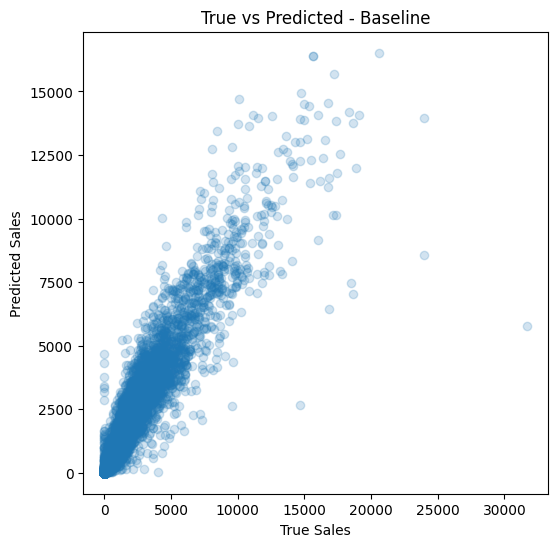

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(results["sales"], results["y_pred"], alpha=0.2)
plt.xlabel("True Sales")
plt.ylabel("Predicted Sales")
plt.title("True vs Predicted - Baseline")
plt.show()

## Error Analysis

Errors are higher during weekends (day 5 and 6), suggesting the model struggles with weekly patterns.

This suggests that the current feature set is not sufficient to fully capture weekly seasonality.

dayofweek
0    121.303272
1    109.947600
2    110.393317
3     98.508174
4    112.067637
5    135.621010
6    154.788305
Name: abs_error, dtype: float64


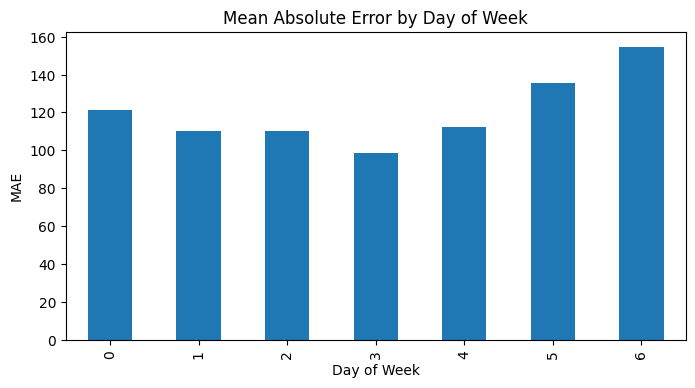

In [19]:
error_by_dayofweek = (
    results.groupby(val_data["dayofweek"])["abs_error"]
    .mean()
    .sort_index()
)

print(error_by_dayofweek)

plt.figure(figsize=(8, 4))
error_by_dayofweek.plot(kind="bar")
plt.title("Mean Absolute Error by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("MAE")
plt.show()

## Conclusion

This baseline establishes a solid starting point for the forecasting task.

Key limitations:
- limited lag features
- no rolling statistics
- basic seasonality modeling

Next improvements will focus on feature engineering and multi-step forecasting strategies.